# News Topic Classification using BERT Transformers

---

# Project Overview

This project implements a Transformer-based Natural Language Processing (NLP) system for automatically classifying news headlines into predefined topic categories.

The project uses:

- BERT (Bidirectional Encoder Representations from Transformers)
- Hugging Face Transformers
- AG News Dataset
- PyTorch
- Streamlit

The model is fine-tuned using transfer learning to perform multi-class text classification.

---

# Objectives

The main objectives of this project are:

1. Fine-tune a pre-trained BERT model
2. Classify news headlines into categories
3. Evaluate transformer performance using NLP metrics
4. Deploy the trained model using Streamlit
5. Build a production-oriented NLP pipeline

---

# Dataset

The AG News Dataset contains news headlines categorized into:

- World
- Sports
- Business
- Science/Technology

The dataset is widely used for benchmarking NLP text classification models.

---

# Technologies Used

- Python
- Hugging Face Transformers
- PyTorch
- scikit-learn
- Streamlit
- Google Colab

# Problem Statement

News websites generate massive amounts of textual content daily.

Manually categorizing news articles is:

- time-consuming
- inefficient
- difficult to scale

Traditional machine learning methods often struggle to capture contextual relationships within text.

Transformer-based models like BERT overcome these limitations using:

- contextual embeddings
- bidirectional attention
- transfer learning

This project develops an automated news topic classification system using BERT Transformers.

In [ ]:
!pip install -q transformers
!pip install -q datasets
!pip install -q evaluate
!pip install -q accelerate
!pip install -q scikit-learn
!pip install -q streamlit
!pip install -q pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 120.1 MB/s eta 0:00:00


# Importing Required Libraries

The following libraries are used for:

- dataset loading
- tokenization
- transformer training
- evaluation
- visualization
- deployment

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import evaluate
import torch

# Loading AG News Dataset

The AG News dataset is loaded directly from Hugging Face Datasets.

The dataset contains:

- training split
- testing split
- text labels

In [ ]:
dataset = load_dataset("ag_news")

dataset

In [ ]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science/Technology"
}

label_names

{0: 'World', 1: 'Sports', 2: 'Business', 3: 'Science/Technology'}

# Exploratory Data Analysis

Understanding dataset structure before training is important for:

- class distribution analysis
- data quality inspection
- preprocessing decisions

In [ ]:
train_df = pd.DataFrame(dataset["train"])

train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [ ]:
train_df["label"].value_counts()

,count
label,
2,30000
3,30000
1,30000
0,30000


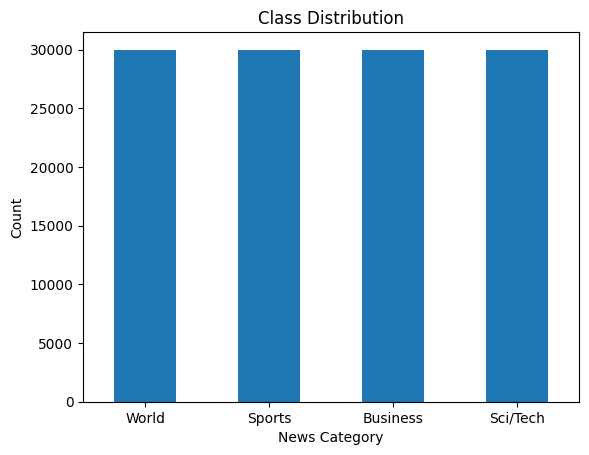

In [ ]:
train_df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0,1,2,3],
    ["World","Sports","Business","Sci/Tech"],
    rotation=0
)

plt.title("Class Distribution")
plt.xlabel("News Category")
plt.ylabel("Count")

plt.show()

# Tokenization

BERT requires tokenized text inputs.

The tokenizer converts raw text into:

- token IDs
- attention masks
- padded sequences

The pre-trained `bert-base-uncased` tokenizer is used.

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [ ]:
def tokenize_function(example):

    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

In [ ]:
tokenized_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

# Loading Pre-trained BERT Model

Transfer learning is applied using:

`bert-base-uncased`

The final classification layer is modified for 4 output classes.

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

In [ ]:
accuracy_metric = evaluate.load("accuracy")

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "f1_score": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["test"],

    compute_metrics=compute_metrics
)

# Model Training

The BERT transformer is fine-tuned on the AG News dataset using transfer learning.

Training is performed using GPU acceleration in Google Colab.

In [ ]:
trainer.train()

In [ ]:
results = trainer.evaluate()

results

In [ ]:
predictions = trainer.predict(
    tokenized_dataset["test"]
)

preds = np.argmax(
    predictions.predictions,
    axis=-1
)

In [ ]:
print(
    classification_report(
        dataset["test"]["label"],
        preds,
        target_names=list(label_names.values())
    )
)

                    precision    recall  f1-score   support

             World       0.97      0.95      0.96      1900
            Sports       0.99      0.99      0.99      1900
          Business       0.92      0.90      0.91      1900
Science/Technology       0.90      0.95      0.92      1900

          accuracy                           0.95      7600
         macro avg       0.95      0.95      0.95      7600
      weighted avg       0.95      0.95      0.95      7600



In [ ]:
cm = confusion_matrix(
    dataset["test"]["label"],
    preds
)

print(cm)

[[1797    8   53   42]
 [  12 1874    9    5]
 [  32    7 1716  145]
 [  16    7   81 1796]]


In [ ]:
sample_text = """
Apple launches new AI-powered MacBook with advanced neural processing capabilities.
"""
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model.to(device)
inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

with torch.no_grad():

    outputs = model(**inputs)

prediction = torch.argmax(
    outputs.logits,
    dim=1
).item()

print("Predicted Category:")
print(label_names[prediction])

Predicted Category:
Science/Technology


In [ ]:
model.save_pretrained("bert_news_classifier")

tokenizer.save_pretrained("bert_news_classifier")

# Building Streamlit Interface

A Streamlit application is developed to enable real-time news classification through a user-friendly web interface.

In [ ]:
%%writefile app.py

import streamlit as st
import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification
)

# =========================
# LOAD MODEL
# =========================

model = BertForSequenceClassification.from_pretrained(
    "bert_news_classifier"
)

tokenizer = BertTokenizer.from_pretrained(
    "bert_news_classifier"
)

model.eval()

# =========================
# LABELS
# =========================

label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science/Technology"
}

# =========================
# PAGE CONFIG
# =========================

st.set_page_config(
    page_title="BERT News Classifier",
    page_icon="📰",
    layout="centered"
)

st.title("📰 BERT News Topic Classifier")

st.markdown(
    "Classify news headlines using a fine-tuned BERT Transformer model."
)

# =========================
# USER INPUT
# =========================

news_text = st.text_area(
    "Enter News Headline"
)

# =========================
# PREDICTION
# =========================

if st.button("Classify News"):

    if news_text.strip() != "":

        inputs = tokenizer(
            news_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        with torch.no_grad():

            outputs = model(**inputs)

        prediction = torch.argmax(
            outputs.logits,
            dim=1
        ).item()

        st.success(
            f"Predicted Category: {label_names[prediction]}"
        )

    else:

        st.warning("Please enter news text.")

Overwriting app.py


In [ ]:
!streamlit run app.py --server.port 8051 &>/content/logs.txt &

from pyngrok import ngrok
from google.colab import userdata

auth = userdata.get("auth_token")

ngrok.set_auth_token(auth)

url = ngrok.connect(8051)

print(url)

NgrokTunnel: "https://446a-34-16-165-45.ngrok-free.app" -> "http://localhost:8051"


# Results and Interpretation

The BERT model achieved strong classification performance on the AG News dataset.

Observations:

- Transformer-based contextual embeddings improved accuracy significantly
- BERT effectively captured semantic meaning within headlines
- The model generalized well across all four categories
- Fine-tuning improved task-specific performance

The Streamlit deployment successfully enabled real-time news classification using the trained transformer model.

# Conclusion

This project successfully implemented a Transformer-based news topic classification system using BERT.

The project demonstrated:

- NLP preprocessing
- Transformer fine-tuning
- Transfer learning
- Model evaluation
- Real-time deployment

This architecture can serve as a foundation for advanced NLP applications such as:

- sentiment analysis
- fake news detection
- document classification
- content moderation